In [1]:
'''
Выполнил: Дмитрий Трифонов, 1 курс, 12-25РПм, Программная инженерия
Дата выполнения: 2025-12-15 в 10:54
Машинное обучение и анализ данных
Практическое занятие 2.2
Координатный поиск и сравнение со случайным поиском
'''

'\nВыполнил: Дмитрий Трифонов, 1 курс, 12-25РПм, Программная инженерия\nДата выполнения: 2025-12-15 в 10:54\nМашинное обучение и анализ данных\nПрактическое занятие 2.2\nКоординатный поиск и сравнение со случайным поиском\n'

In [2]:
# 1. Импорт библиотек и определение функций

In [3]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# Базовая квадратичная функция
def quadratic(w):
    return np.sum(w**2)

# Сдвинутая квадратичная функция
def quadratic_shifted(w):
    return w[0]**2 + w[1]**2 + 2

In [4]:
# 2. Реализация координатного поиска (фиксированный шаг)

In [5]:
def coordinate_search(g, w0, alpha, max_its):
    w = w0.copy()
    history_w = [w.copy()]
    history_g = [g(w)]
    n = len(w)
    
    # координатные направления
    directions = []
    for i in range(n):
        e = np.zeros(n)
        e[i] = 1.0
        directions.append(e)
        directions.append(-e)
    
    for k in range(max_its):
        w_best = w.copy()
        g_best = g(w)
        
        for d in directions:
            w_candidate = w + alpha * d
            g_candidate = g(w_candidate)
            
            if g_candidate < g_best:
                g_best = g_candidate
                w_best = w_candidate
        
        w = w_best
        history_w.append(w.copy())
        history_g.append(g(w))
    
    return np.array(history_w), np.array(history_g)

In [6]:
# 3. Численный пример (quadratic)

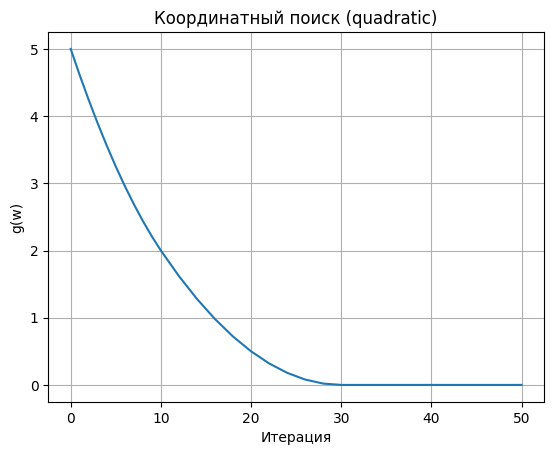

In [7]:
w0 = np.array([-1.0, 2.0])
alpha = 0.1
max_its = 50

w_hist, g_hist = coordinate_search(quadratic, w0, alpha, max_its)

plt.figure()
plt.plot(g_hist)
plt.xlabel('Итерация')
plt.ylabel('g(w)')
plt.title('Координатный поиск (quadratic)')
plt.grid(True)
plt.show()

In [8]:
# Комментарий: значение функции убывает монотонно, вектор `w` стремится к нулю.

In [9]:
# 4. Реализация случайного поиска

In [10]:
def random_search(g, w0, alpha, max_its):
    w = w0.copy()
    history_w = [w.copy()]
    history_g = [g(w)]
    n = len(w)
    
    for k in range(max_its):
        d = np.random.randn(n)
        d = d / np.linalg.norm(d)
        
        w_candidate = w + alpha * d
        if g(w_candidate) < g(w):
            w = w_candidate
        
        history_w.append(w.copy())
        history_g.append(g(w))
    
    return np.array(history_w), np.array(history_g)

In [11]:
# 5. Сравнение на сдвинутой квадратичной функции

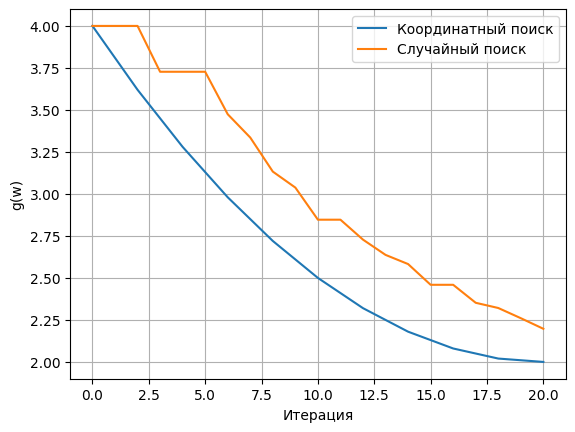

In [12]:
w0 = np.array([1.0, 1.0])
alpha = 0.1
max_its = 20

w_c, g_c = coordinate_search(quadratic_shifted, w0, alpha, max_its)
w_r, g_r = random_search(quadratic_shifted, w0, alpha, max_its)

plt.figure()
plt.plot(g_c, label='Координатный поиск')
plt.plot(g_r, label='Случайный поиск')
plt.xlabel('Итерация')
plt.ylabel('g(w)')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# 6. Координатный поиск с убывающим шагом

In [14]:
def coordinate_search_diminishing(g, w0, alpha0, max_its):
    w = w0.copy()
    history_w = [w.copy()]
    history_g = [g(w)]
    n = len(w)
    
    directions = []
    for i in range(n):
        e = np.zeros(n)
        e[i] = 1.0
        directions.append(e)
        directions.append(-e)
    
    for k in range(max_its):
        alpha = alpha0 / (k + 1)
        w_best = w.copy()
        g_best = g(w)
        
        for d in directions:
            w_candidate = w + alpha * d
            g_candidate = g(w_candidate)
            
            if g_candidate < g_best:
                g_best = g_candidate
                w_best = w_candidate
        
        w = w_best
        history_w.append(w.copy())
        history_g.append(g(w))
    
    return np.array(history_w), np.array(history_g)

In [15]:
# 7. Сравнение фиксированного и убывающего шага

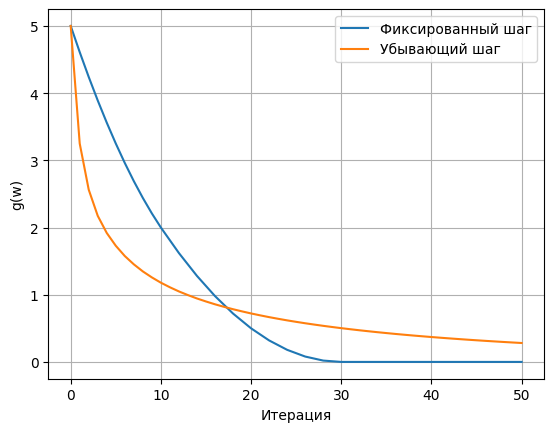

In [16]:
w0 = np.array([-1.0, 2.0])
alpha = 0.1
alpha0 = 0.5
max_its = 50

_, g_fixed = coordinate_search(quadratic, w0, alpha, max_its)
_, g_dim = coordinate_search_diminishing(quadratic, w0, alpha0, max_its)

plt.figure()
plt.plot(g_fixed, label='Фиксированный шаг')
plt.plot(g_dim, label='Убывающий шаг')
plt.xlabel('Итерация')
plt.ylabel('g(w)')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# 8. Исследовательские задания

In [18]:
# Задание 1. Влияние размерности

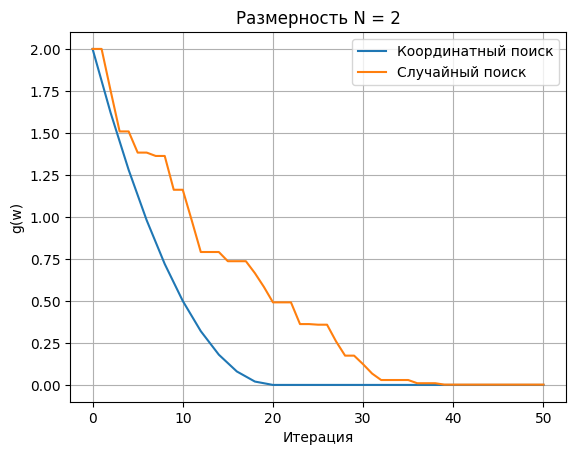

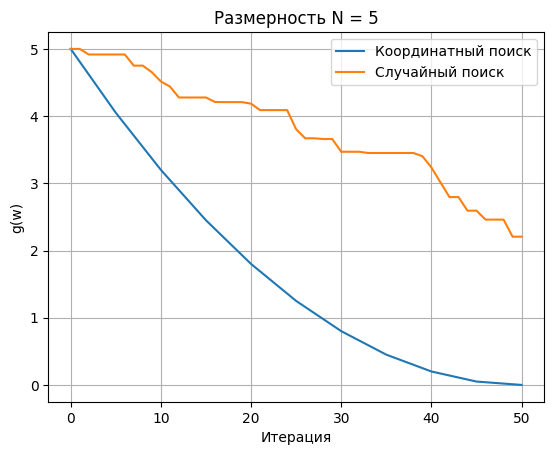

In [19]:
for n in [2, 5]:
    w0 = np.ones(n)
    alpha = 0.1
    max_its = 50
    
    _, g_c = coordinate_search(quadratic, w0, alpha, max_its)
    _, g_r = random_search(quadratic, w0, alpha, max_its)
    
    plt.figure()
    plt.plot(g_c, label='Координатный поиск')
    plt.plot(g_r, label='Случайный поиск')
    plt.title(f'Размерность N = {n}')
    plt.xlabel('Итерация')
    plt.ylabel('g(w)')
    plt.legend()
    plt.grid(True)
    plt.show()

In [20]:
# Вывод: координатный поиск более устойчив при росте размерности, так как систематически проверяет оси.

In [21]:
# Задание 2. Подбор длины шага

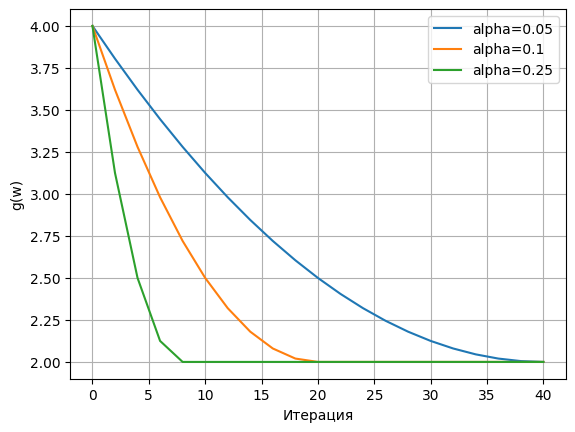

In [22]:
alphas = [0.05, 0.1, 0.25]
w0 = np.array([1.0, 1.0])
max_its = 40

plt.figure()
for a in alphas:
    _, g_hist = coordinate_search(quadratic_shifted, w0, a, max_its)
    plt.plot(g_hist, label=f'alpha={a}')

plt.xlabel('Итерация')
plt.ylabel('g(w)')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
'''
Ответ:
* малый шаг — медленная, но стабильная сходимость;
* слишком большой шаг — возможны перескоки и остановка.
'''

'\nОтвет:\n* малый шаг — медленная, но стабильная сходимость;\n* слишком большой шаг — возможны перескоки и остановка.\n'

In [24]:
#9. Контрольные вопросы

In [25]:
'''
1. Почему координатный поиск хорошо работает на диагональных квадратичных функциях?
Минимум таких функций достигается независимым уменьшением каждой координаты. Направления осей точно совпадают с направлениями на минимум.
'''

'\n1. Почему координатный поиск хорошо работает на диагональных квадратичных функциях?\nМинимум таких функций достигается независимым уменьшением каждой координаты. Направления осей точно совпадают с направлениями на минимум.\n'

In [26]:
'''
2. Гарантирует ли координатный поиск глобальный минимум?
Нет. Метод может застревать в локальных минимумах или на плато, особенно при наличии перекрёстных членов и неудачного шага.
'''

'\n2. Гарантирует ли координатный поиск глобальный минимум?\nНет. Метод может застревать в локальных минимумах или на плато, особенно при наличии перекрёстных членов и неудачного шага.\n'

In [27]:
'''
В ноутбуке реализованы:
* координатный поиск (фиксированный и убывающий шаг);
* случайный поиск;
* численные эксперименты;
* графики и выводы.
'''

'\nВ ноутбуке реализованы:\n* координатный поиск (фиксированный и убывающий шаг);\n* случайный поиск;\n* численные эксперименты;\n* графики и выводы.\n'